# MindMetrix — Core Analysis

**Structure**
1. Data loading & feature extraction
2. Biomarker sensitivity — do signals respond to relaxation?
3. Metadata correlations — do features relate to participant characteristics?
4. PCA — what is the underlying structure of the feature space?
5. Clustering — can we find natural participant groups?

In [64]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import src.preprocessing
import src.features
import src.analysis
importlib.reload(src.preprocessing)
importlib.reload(src.features)
importlib.reload(src.analysis)

from src.preprocessing import preprocess
from src.features import build_feature_matrix
from src.analysis import (
    biomarker_sensitivity_report,
    spearman_with_pvalues,
    mann_whitney_report,
    scale_features,
    run_pca,
    elbow_and_silhouette,
    run_kmeans,
    profile_clusters,
)

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

## 1. Data Loading & Feature Extraction

In [65]:
ts, subjects = preprocess(
    ts_path='data/timeseries.csv',
    subjects_path='data/subjects.csv',
)

feature_matrix = build_feature_matrix(ts, subjects)
feature_matrix.head(3)

[load] timeseries : 14,040,000 rows x 11 cols
[load] subjects   : 500 rows x 8 cols
[clean] Removed 2040000 duplicate timestamp rows (14.53%)
[clean] PupilDiameter out of [0.5, 10.0] mm: 1815432 rows set to NaN (15.13%)
[clean] PulseBPM out of [30, 220] bpm: 0 rows set to NaN (0.00%)
[features] Low-SQI rows (HR excluded from features): 439198 (3.7%)
[features] Feature matrix: 500 subjects x 140 columns


,SubjectID,GazePitch_std_baseline_mean,GazePitch_std_break_mean,GazePitch_std_relax_mean,GazeVelocity_mean_baseline_mean,GazeVelocity_mean_break_mean,GazeVelocity_mean_relax_mean,GazeVelocity_std_baseline_mean,GazeVelocity_std_break_mean,GazeVelocity_std_relax_mean,GazeYaw_std_baseline_mean,GazeYaw_std_break_mean,GazeYaw_std_relax_mean,MotionMag_mean_baseline_mean,MotionMag_mean_break_mean,MotionMag_mean_relax_mean,MotionMag_std_baseline_mean,MotionMag_std_break_mean,MotionMag_std_relax_mean,PPG_SQI_mean_baseline_mean,PPG_SQI_mean_break_mean,PPG_SQI_mean_relax_mean,PulseBPM_mean_baseline_mean,PulseBPM_mean_break_mean,PulseBPM_mean_relax_mean,PulseBPM_std_baseline_mean,PulseBPM_std_break_mean,PulseBPM_std_relax_mean,PupilDiameter_mean_baseline_mean,PupilDiameter_mean_break_mean,PupilDiameter_mean_relax_mean,PupilDiameter_std_baseline_mean,PupilDiameter_std_break_mean,PupilDiameter_std_relax_mean,hr_valid_ratio_baseline_mean,hr_valid_ratio_break_mean,hr_valid_ratio_relax_mean,PulseBPM_relax_delta_mean,PulseBPM_break_delta_mean,PupilDiameter_relax_delta_mean,PupilDiameter_break_delta_mean,MotionMag_relax_delta_mean,MotionMag_break_delta_mean,GazeVelocity_relax_delta_mean,GazeVelocity_break_delta_mean,GazePitch_std_baseline_std,GazePitch_std_break_std,GazePitch_std_relax_std,GazeVelocity_mean_baseline_std,GazeVelocity_mean_break_std,GazeVelocity_mean_relax_std,GazeVelocity_std_baseline_std,GazeVelocity_std_break_std,GazeVelocity_std_relax_std,GazeYaw_std_baseline_std,GazeYaw_std_break_std,GazeYaw_std_relax_std,MotionMag_mean_baseline_std,MotionMag_mean_break_std,MotionMag_mean_relax_std,MotionMag_std_baseline_std,MotionMag_std_break_std,MotionMag_std_relax_std,PPG_SQI_mean_baseline_std,PPG_SQI_mean_break_std,PPG_SQI_mean_relax_std,PulseBPM_mean_baseline_std,PulseBPM_mean_break_std,PulseBPM_mean_relax_std,PulseBPM_std_baseline_std,PulseBPM_std_break_std,PulseBPM_std_relax_std,PupilDiameter_mean_baseline_std,PupilDiameter_mean_break_std,PupilDiameter_mean_relax_std,PupilDiameter_std_baseline_std,PupilDiameter_std_break_std,PupilDiameter_std_relax_std,hr_valid_ratio_baseline_std,hr_valid_ratio_break_std,hr_valid_ratio_relax_std,PulseBPM_relax_delta_std,PulseBPM_break_delta_std,PupilDiameter_relax_delta_std,PupilDiameter_break_delta_std,MotionMag_relax_delta_std,MotionMag_break_delta_std,GazeVelocity_relax_delta_std,GazeVelocity_break_delta_std,GazePitch_std_baseline_trend,GazePitch_std_break_trend,GazePitch_std_relax_trend,GazeVelocity_mean_baseline_trend,GazeVelocity_mean_break_trend,GazeVelocity_mean_relax_trend,GazeVelocity_std_baseline_trend,GazeVelocity_std_break_trend,GazeVelocity_std_relax_trend,GazeYaw_std_baseline_trend,GazeYaw_std_break_trend,GazeYaw_std_relax_trend,MotionMag_mean_baseline_trend,MotionMag_mean_break_trend,MotionMag_mean_relax_trend,MotionMag_std_baseline_trend,MotionMag_std_break_trend,MotionMag_std_relax_trend,PPG_SQI_mean_baseline_trend,PPG_SQI_mean_break_trend,PPG_SQI_mean_relax_trend,PulseBPM_mean_baseline_trend,PulseBPM_mean_break_trend,PulseBPM_mean_relax_trend,PulseBPM_std_baseline_trend,PulseBPM_std_break_trend,PulseBPM_std_relax_trend,PupilDiameter_mean_baseline_trend,PupilDiameter_mean_break_trend,PupilDiameter_mean_relax_trend,PupilDiameter_std_baseline_trend,PupilDiameter_std_break_trend,PupilDiameter_std_relax_trend,hr_valid_ratio_baseline_trend,hr_valid_ratio_break_trend,hr_valid_ratio_relax_trend,PulseBPM_relax_delta_trend,PulseBPM_break_delta_trend,PupilDiameter_relax_delta_trend,PupilDiameter_break_delta_trend,MotionMag_relax_delta_trend,MotionMag_break_delta_trend,GazeVelocity_relax_delta_trend,GazeVelocity_break_delta_trend,STAI_T,STAI_S,Gender,Handedness,WearsGlasses,CalibrationError,BloodType
0,S001,0.228,0.296,0.276,2.448,3.860,3.214,17.144,23.011,21.090,0.360,0.477,0.434,0.079,0.078,0.079,0.047,0.045,0.050,0.877,0.877,0.877,72.015,72.833,71.216,2.581,2.273,2.928,3.771,3.770,3.772,0.025,0.022,0.022,0.999,0.999,0.999,-0.800,0.818,0.002,-0.001,0.000,-0.001,0.766,1.411,0.090,0.044,0.029,1

In [66]:
# Separate physiological feature columns from metadata
METADATA_COLS = ['STAI_T', 'STAI_S', 'Gender', 'Handedness',
                 'WearsGlasses', 'CalibrationError', 'BloodType']
STAI_COLS     = ['STAI_T', 'STAI_S']
BINARY_META   = ['Gender', 'Handedness', 'WearsGlasses']

phys_cols = [c for c in feature_matrix.columns
             if c not in ['SubjectID'] + METADATA_COLS]

print(f'Physiological features : {len(phys_cols)}')
print(f'Subjects               : {len(feature_matrix)}')

Physiological features : 132
Subjects               : 500


## 2. Biomarker Sensitivity

For each physiological signal we test whether signals respond to relaxation and whether participants improve across trials.

**Phase-change tests** (baseline → relax / break):
- **Test**: Wilcoxon signed-rank (non-parametric paired test — no normality assumption)
- **Effect size**: paired Cohen's d
- **Interpretation**: |d| ≥ 0.2 small · ≥ 0.5 medium · ≥ 0.8 large

**Trend tests** (slope across CycleID 1 → 10):
- **Test**: one-sample Wilcoxon signed-rank against zero — is the median slope ≠ 0?
- A negative significant slope means the relaxation response strengthens with practice (learning); positive means it weakens (fatigue).

In [67]:
SENSITIVITY_TESTS = [
    # Phase-change tests
    {'label': 'Heart rate (baseline→relax)',
     'col_a': 'PulseBPM_mean_baseline_mean',
     'col_b': 'PulseBPM_mean_relax_mean'},
    {'label': 'Heart rate (baseline→break)',
     'col_a': 'PulseBPM_mean_baseline_mean',
     'col_b': 'PulseBPM_mean_break_mean'},
    {'label': 'Pupil diameter (baseline→relax)',
     'col_a': 'PupilDiameter_mean_baseline_mean',
     'col_b': 'PupilDiameter_mean_relax_mean'},
    {'label': 'Pupil diameter (baseline→break)',
     'col_a': 'PupilDiameter_mean_baseline_mean',
     'col_b': 'PupilDiameter_mean_break_mean'},
    {'label': 'Motion magnitude (baseline→relax)',
     'col_a': 'MotionMag_mean_baseline_mean',
     'col_b': 'MotionMag_mean_relax_mean'},
    {'label': 'Gaze velocity (baseline→relax)',
     'col_a': 'GazeVelocity_mean_baseline_mean',
     'col_b': 'GazeVelocity_mean_relax_mean'},
    {'label': 'Gaze yaw spread (baseline→relax)',
     'col_a': 'GazeYaw_std_baseline_mean',
     'col_b': 'GazeYaw_std_relax_mean'},
    {'label': 'Gaze pitch spread (baseline→relax)',
     'col_a': 'GazePitch_std_baseline_mean',
     'col_b': 'GazePitch_std_relax_mean'},
    # Trend tests — do participants improve across the 10 trials?
    {'label': 'HR relax delta — trend across trials',
     'col': 'PulseBPM_relax_delta_trend'},
    {'label': 'Pupil relax delta — trend across trials',
     'col': 'PupilDiameter_relax_delta_trend'},
    {'label': 'Motion relax delta — trend across trials',
     'col': 'MotionMag_relax_delta_trend'},
    {'label': 'Gaze velocity relax delta — trend across trials',
     'col': 'GazeVelocity_relax_delta_trend'},
]

sensitivity = biomarker_sensitivity_report(feature_matrix, SENSITIVITY_TESTS)
sensitivity[['label', 'n', 'median_a', 'median_b', 'median_delta', 'median_trend',
             'p_value', 'cohens_d', 'significant']]

,label,n,median_a,median_b,median_delta,median_trend,p_value,cohens_d,significant
0,Heart rate (baseline→relax),500,66.117,64.878,-1.231,NaN,0.000,2.587,True
1,Pupil diameter (baseline→break),500,3.672,3.503,-0.016,NaN,0.000,0.689,True
2,Pupil diameter (baseline→relax),500,3.672,3.462,-0.025,NaN,0.000,0.686,True
3,Gaze pitch spread (baseline→relax),500,0.349,0.366,0.011,NaN,0.000,-0.385,True
4,Gaze yaw spread (baseline→relax),500,0.533,0.561,0.017,NaN,0.000,-0.382,True
5,Gaze velocity (baseline→relax),500,3.263,3.156,-0.078,NaN,0.000,0.260,True
6,Motion magnitude (baseline→relax),500,0.079,0.080,0.000,NaN,0.001,-0.137,True
7,Heart rate (baseline→break),500,66.117,66.090,-0.014,NaN,0.765,0.023,False
8,Motion relax delta — trend across trials,500,NaN,NaN,NaN,-0.000,0.668,-0.019,False
9,HR relax delta — trend across trials,500,NaN,NaN,NaN,0.004,0.453,0.010,False


/var/folders/lg/w8w0chqx34qd_nwpqg7t8rn80000gn/T/ipykernel_25476/2506262720.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/lg/w8w0chqx34qd_nwpqg7t8rn80000gn/T/ipykernel_25476/2506262720.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/lg/w8w0chqx34qd_nwpqg7t8rn80000gn/T/ipykernel_25476/2506262720.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/lg/w8w0chqx34qd_nwpqg7t8rn80000gn/T/ipykernel_25476/2506262720.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since M

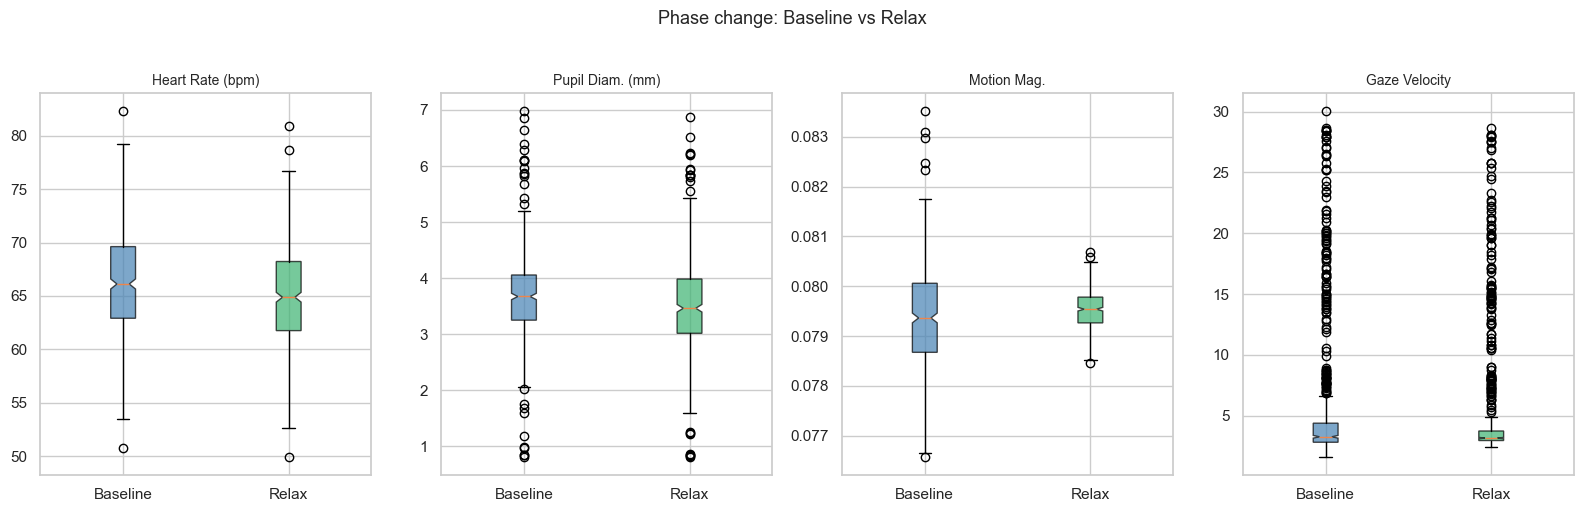

In [68]:
# Paired boxplot — baseline vs relax for the four primary signals
PAIRED_SIGNALS = [
    ('Heart Rate (bpm)',   'PulseBPM_mean_baseline_mean',      'PulseBPM_mean_relax_mean'),
    ('Pupil Diam. (mm)',   'PupilDiameter_mean_baseline_mean', 'PupilDiameter_mean_relax_mean'),
    ('Motion Mag.',        'MotionMag_mean_baseline_mean',     'MotionMag_mean_relax_mean'),
    ('Gaze Velocity',      'GazeVelocity_mean_baseline_mean',  'GazeVelocity_mean_relax_mean'),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, (title, col_a, col_b) in zip(axes, PAIRED_SIGNALS):
    data = feature_matrix[[col_a, col_b]].dropna()
    bp = ax.boxplot(
        [data[col_a], data[col_b]],
        labels=['Baseline', 'Relax'],
        patch_artist=True,
        notch=True,
    )
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('mediumseagreen')
    for box in bp['boxes']:
        box.set_alpha(0.7)

    # Annotate with p-value and Cohen's d
    row = sensitivity[sensitivity['label'].str.startswith(title.split(' (')[0])]
    if not row.empty:
        r = row.iloc[0]
        ax.set_title(
            f"{title}\np={r['p_value']:.3f}  d={r['cohens_d']:.2f}",
            fontsize=10,
        )
    else:
        ax.set_title(title, fontsize=10)

plt.suptitle('Phase change: Baseline vs Relax', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. Metadata Correlations

### 3a. Continuous metadata — Spearman correlation with STAI scores

Spearman rank correlation captures monotonic relationships without assuming
linearity or normality. We focus on **delta features** (intra-participant
change) and **baseline means** (inter-participant level).

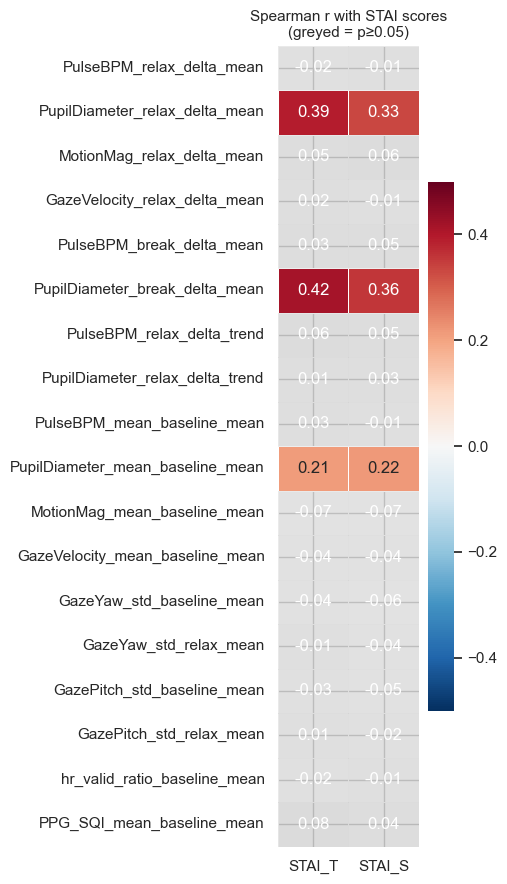


Significant correlations (p<0.05):

STAI_T:
PupilDiameter_break_delta_mean     0.415
PupilDiameter_relax_delta_mean     0.393
PupilDiameter_mean_baseline_mean   0.212

STAI_S:
PupilDiameter_break_delta_mean     0.359
PupilDiameter_relax_delta_mean     0.334
PupilDiameter_mean_baseline_mean   0.218


In [69]:
KEY_FEATURES = [
    # Intra-participant: relaxation response
    'PulseBPM_relax_delta_mean',
    'PupilDiameter_relax_delta_mean',
    'MotionMag_relax_delta_mean',
    'GazeVelocity_relax_delta_mean',
    # Intra-participant: recovery
    'PulseBPM_break_delta_mean',
    'PupilDiameter_break_delta_mean',
    # Intra-participant: adaptation trend across trials
    'PulseBPM_relax_delta_trend',
    'PupilDiameter_relax_delta_trend',
    # Inter-participant: absolute baseline level
    'PulseBPM_mean_baseline_mean',
    'PupilDiameter_mean_baseline_mean',
    'MotionMag_mean_baseline_mean',
    'GazeVelocity_mean_baseline_mean',
    # Gaze spread per phase (no delta — mean direction is arbitrary)
    'GazeYaw_std_baseline_mean',
    'GazeYaw_std_relax_mean',
    'GazePitch_std_baseline_mean',
    'GazePitch_std_relax_mean',
    # Signal quality
    'hr_valid_ratio_baseline_mean',
    'PPG_SQI_mean_baseline_mean',
]

# Keep only columns that actually exist in the feature matrix
KEY_FEATURES = [c for c in KEY_FEATURES if c in feature_matrix.columns]

corr_df, pval_df = spearman_with_pvalues(feature_matrix, KEY_FEATURES, STAI_COLS)

# Mask non-significant correlations
sig_mask = pval_df >= 0.05

fig, ax = plt.subplots(figsize=(5, 9))
sns.heatmap(
    corr_df, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-0.5, vmax=0.5,
    mask=sig_mask,          # grey-out non-significant cells
    linewidths=0.5, ax=ax,
)
# Draw non-significant cells greyed out
sns.heatmap(
    corr_df, annot=True, fmt='.2f', cmap='Greys',
    center=0, vmin=-1, vmax=1, alpha=0.3,
    mask=~sig_mask, linewidths=0.5, ax=ax,
    cbar=False,
)
ax.set_title('Spearman r with STAI scores\n(greyed = p≥0.05)', fontsize=11)
plt.tight_layout()
plt.show()

print('\nSignificant correlations (p<0.05):')
for target in STAI_COLS:
    sig = corr_df[target][pval_df[target] < 0.05].sort_values(key=abs, ascending=False)
    print(f'\n{target}:')
    print(sig.to_string())

### 3b. Binary metadata — Mann-Whitney U

Non-parametric group comparison for Gender, Handedness, and WearsGlasses.

In [70]:
for col in BINARY_META:
    report = mann_whitney_report(feature_matrix, KEY_FEATURES, group_col=col)
    sig = report[report['significant']]
    print(f'\n--- {col} ---')
    if sig.empty:
        print('No significant differences found.')
    else:
        print(sig[['feature', 'group_a', 'group_b', 'median_a', 'median_b', 'p_value']].to_string(index=False))


--- Gender ---
                         feature group_a group_b  median_a  median_b  p_value
     PulseBPM_mean_baseline_mean       F       M    68.275    64.038    0.000
PupilDiameter_mean_baseline_mean       F       M     3.608     3.731    0.017

--- Handedness ---
                     feature group_a group_b  median_a  median_b  p_value
hr_valid_ratio_baseline_mean       L       R     0.999     0.999    0.012

--- WearsGlasses ---
                     feature  group_a  group_b  median_a  median_b  p_value
hr_valid_ratio_baseline_mean        0        1     0.999     0.999    0.020


## 4. PCA

PCA reduces the high-dimensional feature space to a few interpretable axes.
We run it on **all physiological features** (standardised) to understand the
main sources of inter-subject variation before clustering.

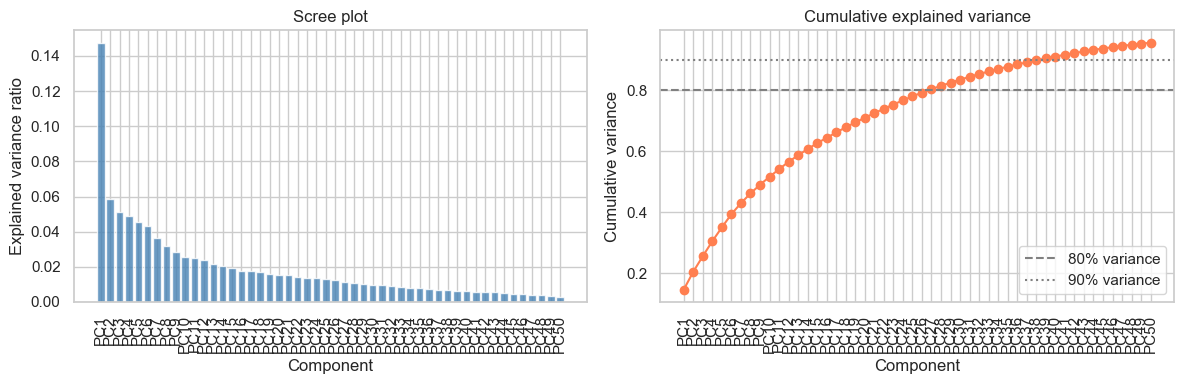

component  explained_variance_ratio  cumulative_variance
      PC1                     0.147                0.147
      PC2                     0.059                0.206
      PC3                     0.051                0.257
      PC4                     0.049                0.306
      PC5                     0.045                0.351
      PC6                     0.043                0.394
      PC7                     0.036                0.430
      PC8                     0.032                0.462
      PC9                     0.029                0.491
     PC10                     0.026                0.516


In [71]:
X_scaled, scaler = scale_features(feature_matrix, phys_cols)
pca, scores_df, variance_df, loadings_df = run_pca(X_scaled, phys_cols)

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

n_show = min(50, len(variance_df))
axes[0].bar(variance_df['component'][:n_show],
            variance_df['explained_variance_ratio'][:n_show],
            color='steelblue', alpha=0.8)
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Explained variance ratio')
axes[0].set_title('Scree plot')
axes[0].tick_params(axis='x', rotation=90)

axes[1].plot(variance_df['component'][:n_show],
             variance_df['cumulative_variance'][:n_show],
             marker='o', color='coral')
axes[1].axhline(0.8, linestyle='--', color='grey', label='80% variance')
axes[1].axhline(0.9, linestyle=':', color='grey', label='90% variance')
axes[1].set_xlabel('Component')
axes[1].set_ylabel('Cumulative variance')
axes[1].set_title('Cumulative explained variance')
axes[1].tick_params(axis='x', rotation=90)
axes[1].legend()

plt.tight_layout()
plt.show()

print(variance_df.head(10).to_string(index=False))

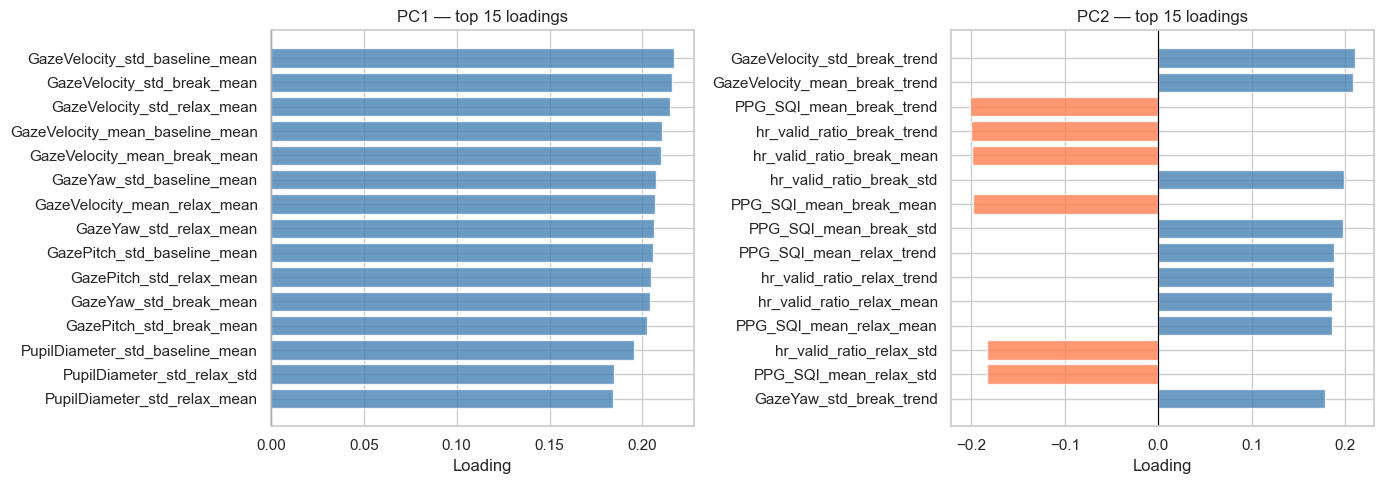

In [72]:
# Top feature loadings for PC1 and PC2
N_TOP = 15

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pc in zip(axes, ['PC1', 'PC2']):
    top = loadings_df.loc[pc].abs().nlargest(N_TOP).index
    vals = loadings_df.loc[pc, top]
    colors = ['steelblue' if v > 0 else 'coral' for v in vals]
    ax.barh(top[::-1], vals[::-1], color=colors[::-1], alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{pc} — top {N_TOP} loadings')
    ax.set_xlabel('Loading')

plt.tight_layout()
plt.show()

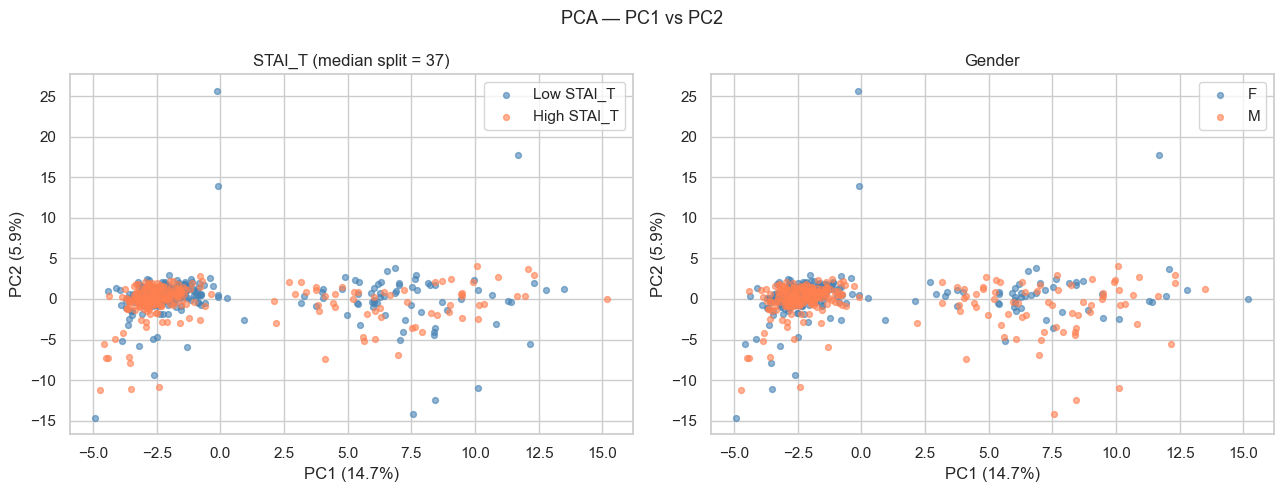

In [73]:
# PC1 vs PC2 scatter coloured by STAI_T (high vs low anxiety)
stai_median = feature_matrix['STAI_T'].median()
anxiety_group = (feature_matrix['STAI_T'] > stai_median).map(
    {True: 'High STAI_T', False: 'Low STAI_T'}
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (group_col, title) in zip(axes, [
    (anxiety_group, f'STAI_T (median split = {stai_median:.0f})'),
    (feature_matrix['Gender'], 'Gender'),
]):
    for label, color in zip(group_col.unique(), ['steelblue', 'coral']):
        mask = group_col == label
        ax.scatter(
            scores_df.loc[mask, 'PC1'],
            scores_df.loc[mask, 'PC2'],
            s=18, alpha=0.6, label=label, color=color,
        )
    ax.set_xlabel(f"PC1 ({variance_df.loc[0,'explained_variance_ratio']:.1%})")
    ax.set_ylabel(f"PC2 ({variance_df.loc[1,'explained_variance_ratio']:.1%})")
    ax.set_title(title)
    ax.legend()

plt.suptitle('PCA — PC1 vs PC2', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Clustering

K-Means clustering is applied on the **PCA scores** (first N components that
explain ≥80% variance) to avoid the curse of dimensionality.

The optimal K is selected by inspecting the **elbow plot** (inertia) and the
**silhouette score** jointly.

Using first 27 PCA components (≥80% variance explained)


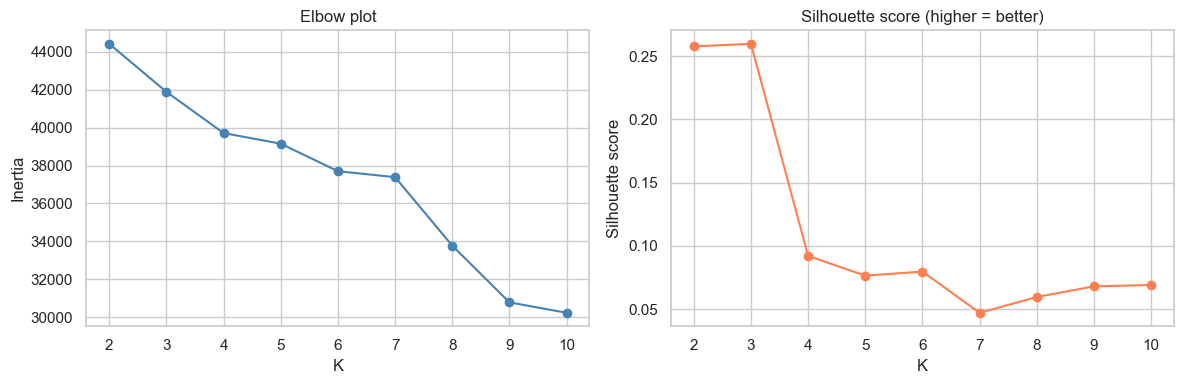

 k   inertia  silhouette_score
 2 44420.441             0.258
 3 41888.101             0.260
 4 39712.012             0.092
 5 39151.278             0.077
 6 37698.115             0.080
 7 37384.735             0.047
 8 33769.570             0.060
 9 30777.627             0.068
10 30225.124             0.069


In [74]:
# Select components that together explain >=80% of variance
n_pca_components = int((variance_df['cumulative_variance'] < 0.80).sum()) + 1
print(f'Using first {n_pca_components} PCA components (≥80% variance explained)')

X_pca = scores_df.iloc[:, :n_pca_components].values

# Elbow + silhouette for K in [2, 10]
k_metrics = elbow_and_silhouette(X_pca, k_range=range(2, 11))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_metrics['k'], k_metrics['inertia'], marker='o', color='steelblue')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow plot')
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(1))

axes[1].plot(k_metrics['k'], k_metrics['silhouette_score'], marker='o', color='coral')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette score (higher = better)')
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.tight_layout()
plt.show()

print(k_metrics.to_string(index=False))

In [75]:
# Set K based on the elbow/silhouette plots above
K_OPTIMAL = 3  # <-- adjust after inspecting the plots

km, cluster_labels = run_kmeans(X_pca, k=K_OPTIMAL)

[clustering] K-Means (k=3) — cluster sizes: {np.int32(0): np.int64(23), np.int32(1): np.int64(118), np.int32(2): np.int64(359)}


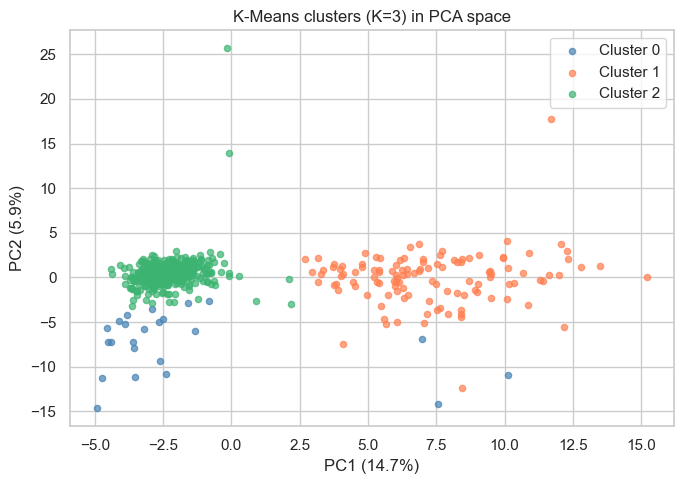

In [76]:
# PCA scatter coloured by cluster
palette = ['steelblue', 'coral', 'mediumseagreen', 'orchid', 'goldenrod']

fig, ax = plt.subplots(figsize=(7, 5))
for k in range(K_OPTIMAL):
    mask = cluster_labels == k
    ax.scatter(
        scores_df.loc[mask, 'PC1'],
        scores_df.loc[mask, 'PC2'],
        s=20, alpha=0.7, label=f'Cluster {k}', color=palette[k],
    )

ax.set_xlabel(f"PC1 ({variance_df.loc[0,'explained_variance_ratio']:.1%})")
ax.set_ylabel(f"PC2 ({variance_df.loc[1,'explained_variance_ratio']:.1%})")
ax.set_title(f'K-Means clusters (K={K_OPTIMAL}) in PCA space')
ax.legend()
plt.tight_layout()
plt.show()

In [77]:
# Cluster profiling — metadata + key biomarkers
PROFILE_COLS = [
    'STAI_T', 'STAI_S',
    'PulseBPM_mean_baseline_mean',
    'PulseBPM_relax_delta_mean',
    'PupilDiameter_mean_baseline_mean',
    'PupilDiameter_relax_delta_mean',
    'MotionMag_mean_baseline_mean',
    'MotionMag_relax_delta_mean',
    'GazeVelocity_relax_delta_mean',
    'GazeYaw_std_relax_mean',
    'GazePitch_std_relax_mean',
    'PulseBPM_relax_delta_trend',
    'PPG_SQI_mean_baseline_mean',
]
PROFILE_COLS = [c for c in PROFILE_COLS if c in feature_matrix.columns]

profile = profile_clusters(feature_matrix.reset_index(drop=True), cluster_labels, PROFILE_COLS)
profile

STAI_T        STAI_S        PulseBPM_mean_baseline_mean        \
          mean    std   mean    std                        mean   std   
cluster                                                                 
0       46.652 15.044 42.609 12.194                      66.039 4.244   
1       40.305 12.914 38.966 11.366                      66.334 4.286   
2       39.953 13.424 38.816 10.766                      66.229 4.928   

        PulseBPM_relax_delta_mean       PupilDiameter_mean_baseline_mean  \
                             mean   std                             mean   
cluster                                                                    
0                          -1.213 0.653                            3.698   
1                          -1.169 0.454                            3.883   
2                          -1.238 0.463                            3.625   

              PupilDiameter_relax_delta_mean        \
          std                           mean   std   
cluster                                              
0       0.657                         -0.080 0.198   
1       1.343                         -0.161 0.245   
2       0.494                         -0.189 0.265   

        MotionMag_mean_baseline_mean       MotionMag_relax_delta_mean        \
                                mean   std                       mean   std   
cluster                                                                       
0                              0.079 0.001                      0.000 0.001   
1                              0.079 0.001                      0.000 0.001   
2                              0.079 0.001                      0.000 0.001   

        GazeVelocity_relax_delta_mean       GazeYaw_std_relax_mean        \
                                 mean   std                   mean   std   
cluster                                                                    
0                               0.190 1.082                  0.561 0.201   
1                              -1.241 1.833                  1.083 0.209   
2                              -0.023 0.577                  0.515 0.095   

        GazePitch_std_relax_mean       PulseBPM_relax_delta_trend        \
                            mean   std                       mean   std   
cluster                                                                   
0                          0.378 0.150                     -0.112 0.496   
1                          0.692 0.167                     -0.013 0.157   
2                          0.343 0.062                      0.014 0.168   

        PPG_SQI_mean_baseline_mean        
                              mean   std  
cluster                                   
0                            0.869 0.025  
1                            0.876 0.001  
2                            0.876 0.001

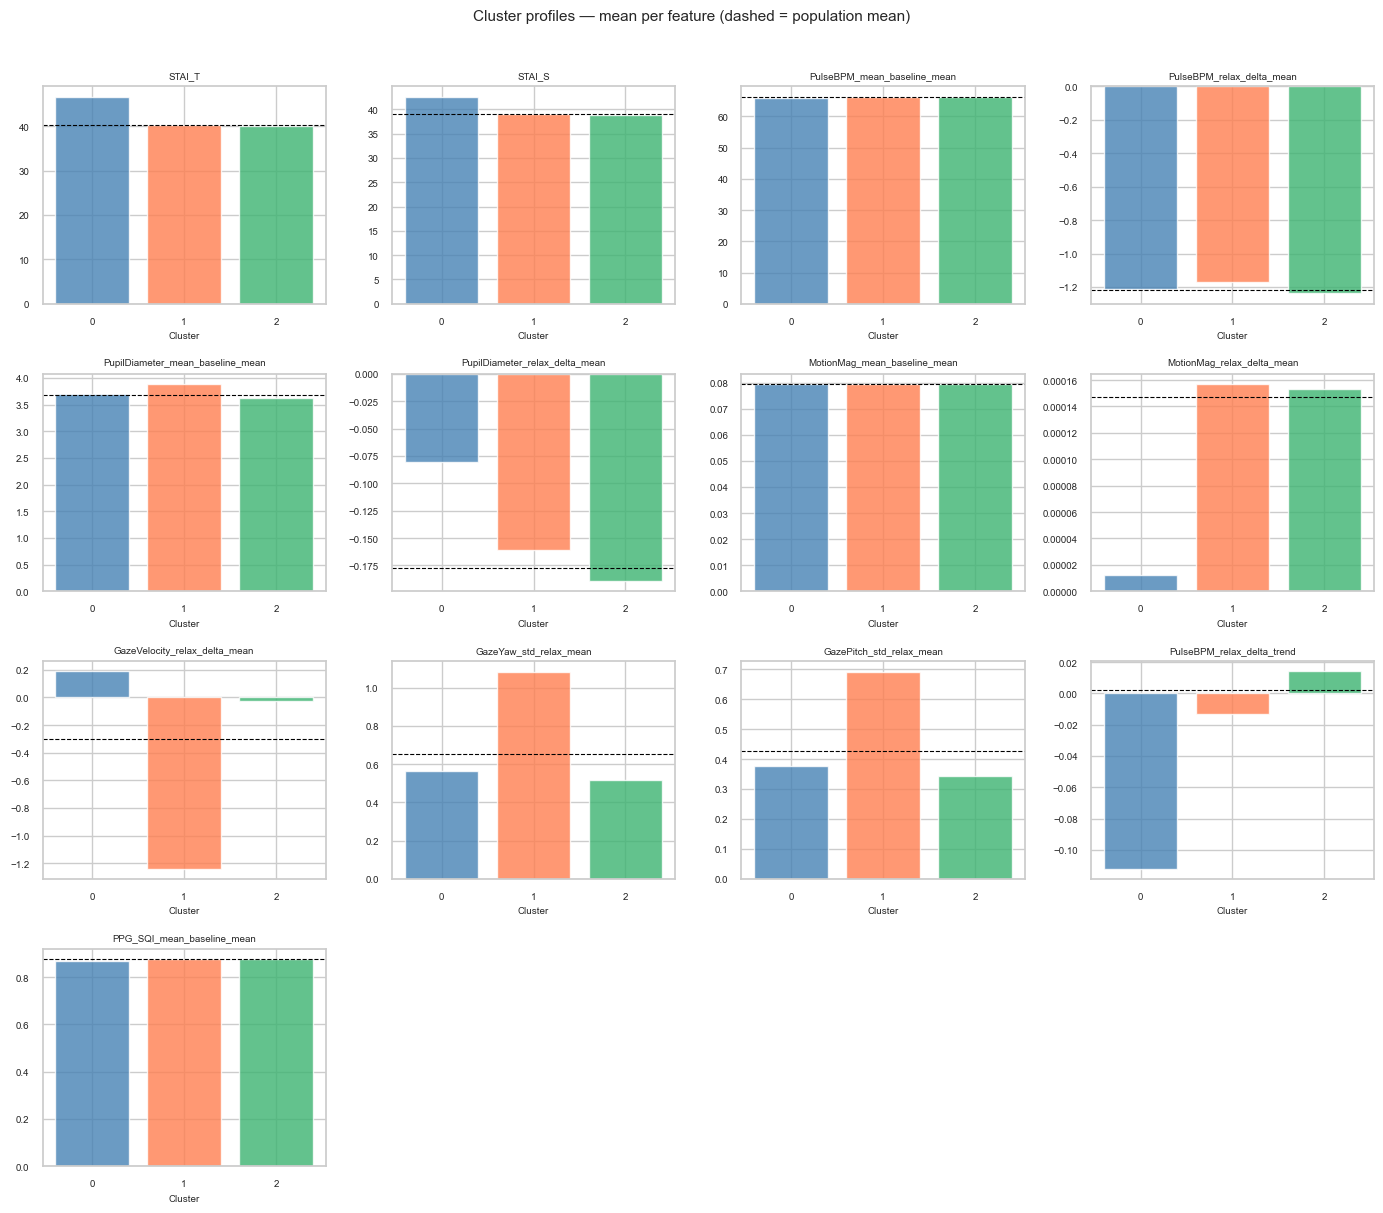

In [78]:
# Visual cluster profile — one subplot per feature with its own y-axis
profile_data = (
    feature_matrix.reset_index(drop=True)
    .assign(cluster=cluster_labels)[PROFILE_COLS + ['cluster']]
)
profile_means = profile_data.groupby('cluster')[PROFILE_COLS].mean()

n_cols = 4
n_rows = int(np.ceil(len(PROFILE_COLS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, PROFILE_COLS):
    vals = profile_means[col]
    bars = ax.bar(vals.index.astype(str), vals.values, color=palette[:K_OPTIMAL], alpha=0.8)
    ax.set_title(col, fontsize=7, wrap=True)
    ax.set_xlabel('Cluster', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.axhline(profile_data[col].mean(), color='black', linewidth=0.8, linestyle='--', label='mean')

# Hide unused subplots
for ax in axes[len(PROFILE_COLS):]:
    ax.set_visible(False)

plt.suptitle('Cluster profiles — mean per feature (dashed = population mean)', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()